## 프로젝트 개요

**목표**: 서울의 실제 날씨 데이터를 API로 수집하고, Oracle DB의 배달 주문 데이터와 결합해서
"비 오는 날엔 어떤 메뉴가 더 잘 팔리는지" 분석하고, 그 결과를 Gradio 화면으로 출력

## 필수 스킬

| 단계 | 사용 기술 | 포인트 |
|---|---|---|
| 1. 날씨 데이터 수집 | `requests`로 외부 API 호출 (Open-Meteo, 무료·키 불필요) | **신규** — API 크롤링 |
| 2. 배달 주문 데이터 조회 | Oracle DB 연결 (`.env` + `with` 구문) | Chapter02 ex01 |
| 3. 데이터 결합 | `pd.merge()`, `groupby()`, `pivot_table()` | Chapter01, Chapter02 ex09 |
| 4. 통계 분석 | `numpy`로 상관관계, 그룹별 평균 비교 | Chapter02 ex02, ex10 |
| 5. 파일 저장 | `to_csv()`로 중간/최종 결과 저장 | 신규 (파일 저장 습관) |
| 6. 시각화 | `matplotlib` + `seaborn` (색상/라벨 커스터마이징) | Chapter02 ex03~06 |
| 7. 화면 구성 | `gr.Blocks` + 커스텀 테마/CSS | Chapter03 ex08, ex10 |

### 사전 준비
- Chapter02의 `.env`, `DELIVERY_ORDERS` 테이블이 그대로 필요
- 추가 설치: `uv pip install requests`

## Part 1. 라이브러리 및 환경 설정

In [1]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import gradio as gr


# ─────────────────────────────────────────────────────────
# 차트 디자인 공통 설정
#   - seaborn의 "whitegrid" 테마로 배경을 깔끔하게
#   - font_scale로 전체적인 글자 크기를 살짝 키움
# ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)

# ─────────────────────────────────────────────────────────
mpl.rc('font', family='Malgun Gothic')  # Mac은 'AppleGothic'
mpl.rc('axes', unicode_minus=False)

# 카테고리마다 고정된 색을 지정해두면, 어떤 그래프에서도
# "치킨은 항상 주황색"처럼 색이 일관돼서 보기 편합니다.
CATEGORY_COLORS = {
    "분식": "#FF6B6B",
    "치킨": "#FFA94D",
    "피자": "#FFD43B",
    "중식": "#69DB7C",
    "일식": "#4DABF7",
}

load_dotenv()
USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")

SAVE_DIR = "data"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"'{SAVE_DIR}' 폴더 준비 완료")

c:\source\pythonsource\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'data' 폴더 준비 완료


## Part 2. Oracle DB에서 배달 주문 데이터 조회 (Chapter02 복습)

`.env` + `with` 구문 패턴을 그대로 재사용합니다.
`insert_extra_for_chart.sql`을 먼저 실행해두셔야 데이터가 충분합니다.

In [3]:
with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    orders_df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)
# with 블록을 벗어나는 순간 자동으로 연결이 닫힘

orders_df["ORDER_DATE"] = pd.to_datetime(orders_df["ORDER_DATE"])
print(f"전체 주문 데이터 : {len(orders_df)}건")
orders_df.head()

DatabaseError: DPY-4001: no credentials specified

In [3]:
start_date = orders_df["ORDER_DATE"].min().strftime("%Y-%m-%d")
end_date = orders_df["ORDER_DATE"].max().strftime("%Y-%m-%d")
print(f"주문 데이터 날짜 범위 : {start_date} ~ {end_date}")

# 참고: end_date가 오늘 이후라면 날씨 API에서 데이터를 가져올 수 없습니다.
# insert_extra_for_chart.sql은 오늘 날짜(9/02) 이내로 맞춰뒀습니다.

주문 데이터 날짜 범위 : 2026-08-01 ~ 2026-09-02


## Part 3. 날씨 API 크롤링 (신규 — Open-Meteo)

**Open-Meteo**는 회원가입/API 키 없이 무료로 쓸 수 있는 날씨 API입니다.
`/v1/archive` 엔드포인트로 과거 특정 기간의 날씨(기온, 강수량)를 가져올 수 있습니다.

In [4]:
SEOUL_LAT = 37.5665
SEOUL_LON = 126.9780

def fetch_seoul_weather(start, end):
    """
    Open-Meteo 히스토리컬 날씨 API를 호출해서
    지정된 기간의 서울 날씨(최고/최저기온, 강수량)를 DataFrame으로 반환하는 함수.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": SEOUL_LAT,
        "longitude": SEOUL_LON,
        "start_date": start,
        "end_date": end,
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
        "timezone": "Asia/Seoul",
    }

    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()

    weather_df = pd.DataFrame(data["daily"])
    weather_df.columns = ["ORDER_DATE", "최고기온", "최저기온", "강수량"]
    weather_df["ORDER_DATE"] = pd.to_datetime(weather_df["ORDER_DATE"])
    return weather_df


weather_df = fetch_seoul_weather(start_date, end_date)
print(f"날씨 데이터 {len(weather_df)}일치 수집 완료")
weather_df.head()

날씨 데이터 33일치 수집 완료


,ORDER_DATE,최고기온,최저기온,강수량
0,2026-08-01,32.8,26.1,2.2
1,2026-08-02,34.1,26.3,0.0
2,2026-08-03,37.2,25.3,0.1
3,2026-08-04,36.6,28.7,2.7
4,2026-08-05,37.5,26.8,5.7


In [5]:
weather_csv_path = os.path.join(SAVE_DIR, "weather_seoul.csv")
weather_df.to_csv(weather_csv_path, index=False, encoding="utf-8-sig")
print(f"날씨 데이터 저장 완료 : {weather_csv_path}")

날씨 데이터 저장 완료 : data\weather_seoul.csv


## Part 4. 주문 데이터 + 날씨 데이터 결합 (Chapter01/02 복습)

In [6]:
daily_category = (
    orders_df.groupby(["ORDER_DATE", "CATEGORY"])
    .size()
    .reset_index(name="주문건수")
)
merged_df = pd.merge(daily_category, weather_df, on="ORDER_DATE", how="left")
merged_df["날씨구분"] = np.where(merged_df["강수량"] > 0, "비", "맑음")

print(f"결합된 데이터 : {len(merged_df)}행")
merged_df.head(10)

결합된 데이터 : 53행


,ORDER_DATE,CATEGORY,주문건수,최고기온,최저기온,강수량,날씨구분
0,2026-08-01,분식,1,32.8,26.1,2.2,비
1,2026-08-02,치킨,1,34.1,26.3,0.0,맑음
2,2026-08-03,피자,1,37.2,25.3,0.1,비
3,2026-08-04,중식,1,36.6,28.7,2.7,비
4,2026-08-05,중식,1,37.5,26.8,5.7,비
5,2026-08-06,일식,1,38.6,28.8,0.0,맑음
6,2026-08-07,중식,1,38.4,29.4,0.6,비
7,2026-08-08,분식,2,34.2,25.2,12.7,비
8,2026-08-09,치킨,2,32.7,23.8,0.2,비
9,2026-08-10,치킨,1,34.2,21.9,2.4,비


## Part 5. numpy 분석 + 시각화 (Chapter02 복습, 디자인 강화)

카테고리별 고정 색상, 막대 위 숫자 라벨, 큰 제목 폰트를 적용해서
그래프가 한눈에 잘 읽히도록 꾸몄습니다.

In [7]:
weather_category_pivot = pd.pivot_table(
    merged_df, values="주문건수", index="CATEGORY", columns="날씨구분",
    aggfunc="mean", fill_value=0,
).round(2)
weather_category_pivot["증감량(비-맑음)"] = (
    weather_category_pivot["비"] - weather_category_pivot["맑음"]
)
weather_category_pivot_sorted = weather_category_pivot.sort_values("증감량(비-맑음)", ascending=False)

print("=== 비 오는 날 주문이 더 느는 카테고리 순위 ===")
print(weather_category_pivot_sorted)

=== 비 오는 날 주문이 더 느는 카테고리 순위 ===
날씨구분       맑음     비  증감량(비-맑음)
CATEGORY                      
분식        0.0  1.90       1.90
치킨        1.0  1.60       0.60
일식        1.0  1.30       0.30
중식        2.0  1.11      -0.89
피자        2.0  1.10      -0.90


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\2147044652.py:28: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\2147044652.py:28: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\2147044652.py:28: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\2147044652.py:28: UserWarning: Glyph 53416 (\N{HANGUL SYLLABLE KIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\2147044652.py:28: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\2147044652.py:28: UserWarning: Glyph 514

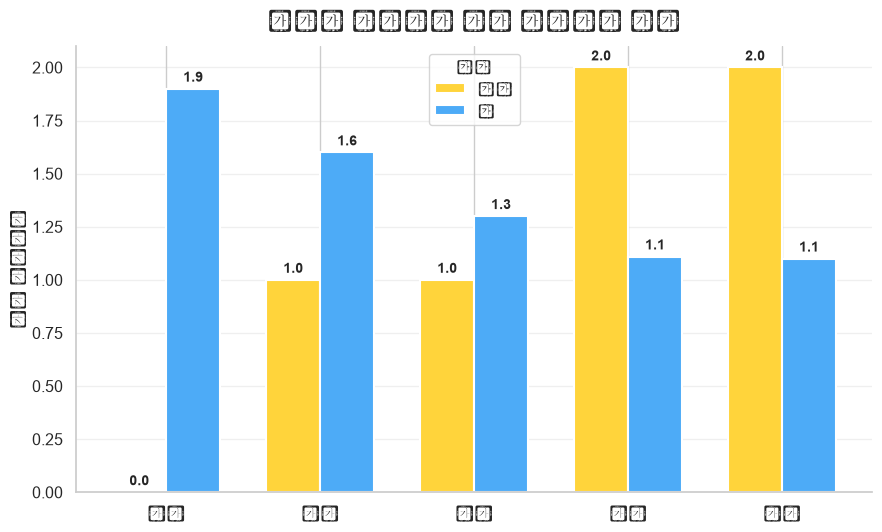

In [8]:
# ─────────────────────────────────────────────────────────
# 시각화 1 : 카테고리별 "맑음 vs 비" 평균 주문건수 (색상 + 숫자 라벨)
# ─────────────────────────────────────────────────────────
categories_order = weather_category_pivot_sorted.index.tolist()
sunny_values = weather_category_pivot_sorted["맑음"].values
rainy_values = weather_category_pivot_sorted["비"].values

x = np.arange(len(categories_order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
bars1 = ax.bar(x - width/2, sunny_values, width, label="맑음",
               color="#FFD43B", edgecolor="white", linewidth=1.5)
bars2 = ax.bar(x + width/2, rainy_values, width, label="비",
               color="#4DABF7", edgecolor="white", linewidth=1.5)

# 막대 위에 정확한 값을 숫자로 표시 (bar_label)
ax.bar_label(bars1, padding=3, fontsize=10, fontweight="bold", fmt="%.1f")
ax.bar_label(bars2, padding=3, fontsize=10, fontweight="bold", fmt="%.1f")

ax.set_title("날씨별 카테고리 평균 주문건수 비교", fontsize=16, fontweight="bold", pad=14)
ax.set_ylabel("평균 주문건수", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories_order, fontsize=12)
ax.legend(title="날씨", fontsize=11, title_fontsize=11, frameon=True)
sns.despine(left=False, bottom=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\3378641846.py:22: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\3378641846.py:22: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\3378641846.py:22: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\3378641846.py:22: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\3378641846.py:22: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\3378641846.py:22: UserWarning: Glyph 4753

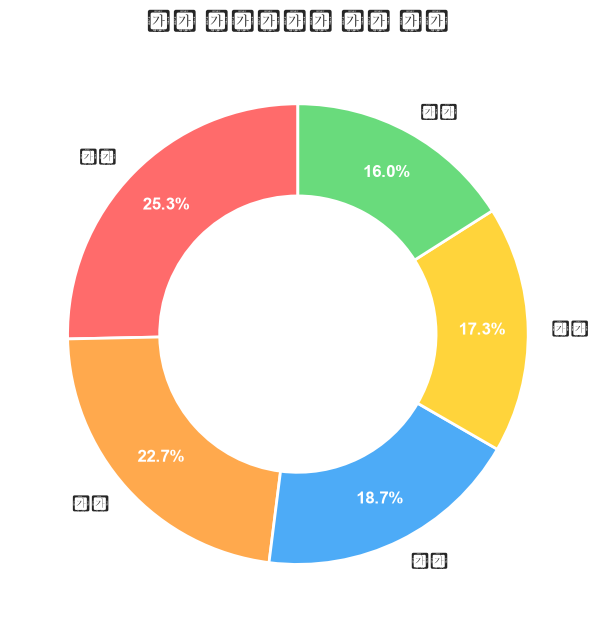

In [9]:
# ─────────────────────────────────────────────────────────
# 시각화 2 : 카테고리별 전체 주문 비중 (도넛 차트 - 카테고리 고정색 적용)
# ─────────────────────────────────────────────────────────
category_totals = orders_df["CATEGORY"].value_counts()
colors = [CATEGORY_COLORS.get(cat, "#ADB5BD") for cat in category_totals.index]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
wedges, texts, autotexts = ax.pie(
    category_totals.values,
    labels=category_totals.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8,
    textprops={"fontsize": 12, "fontweight": "bold"},
    wedgeprops={"width": 0.4, "edgecolor": "white", "linewidth": 2},  # 도넛 모양
)
for autotext in autotexts:
    autotext.set_color("white")

ax.set_title("전체 카테고리별 주문 비중", fontsize=16, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

In [10]:
# 강수량과 총 주문건수의 상관계수 (Chapter02 ex02 복습)
daily_total = merged_df.groupby("ORDER_DATE").agg(
    총주문건수=("주문건수", "sum"),
    강수량=("강수량", "first"),
).reset_index()

corr_matrix = np.corrcoef(daily_total["강수량"], daily_total["총주문건수"])
corr_value = corr_matrix[0, 1]
print(f"강수량-총주문건수 상관계수 : {corr_value:.3f}")

if corr_value > 0.3:
    print("-> 비가 많이 온 날일수록 전체 배달 주문이 늘어나는 경향이 있습니다.")
elif corr_value < -0.3:
    print("-> 비가 많이 온 날일수록 전체 배달 주문이 줄어드는 경향이 있습니다.")
else:
    print("-> 강수량과 전체 주문건수 사이에 뚜렷한 관계는 보이지 않습니다.")

강수량-총주문건수 상관계수 : 0.270
-> 강수량과 전체 주문건수 사이에 뚜렷한 관계는 보이지 않습니다.


## Part 6. 분석 결과 파일 저장

In [11]:
merged_csv_path = os.path.join(SAVE_DIR, "merged_weather_orders.csv")
merged_df.to_csv(merged_csv_path, index=False, encoding="utf-8-sig")

summary_csv_path = os.path.join(SAVE_DIR, "weather_category_summary.csv")
weather_category_pivot_sorted.to_csv(summary_csv_path, encoding="utf-8-sig")

print(f"결합 데이터 저장 완료 : {merged_csv_path}")
print(f"요약 분석 저장 완료   : {summary_csv_path}")

결합 데이터 저장 완료 : data\merged_weather_orders.csv
요약 분석 저장 완료   : data\weather_category_summary.csv


## Part 7. Gradio 대시보드 (Chapter03 복습, 디자인 전면 개편)

이번엔 화면 자체를 꾸며봅니다.
- **테마**: `gr.themes.Soft`로 기본 제공 테마 중 부드러운 스타일 적용
- **커스텀 CSS**: 글자 크기, 카드 모서리, 그림자, 배너 등을 직접 지정
- **컬러 배너**: 상단에 그라데이션 배경의 타이틀 영역 추가

In [12]:
# ─────────────────────────────────────────────────────────
# 커스텀 CSS : 전체적으로 글자 크기를 키우고, 카드 모서리를 둥글게,
#              버튼과 입력창에 그림자를 넣어 화면을 화사하게 만듭니다.
# ─────────────────────────────────────────────────────────
custom_css = """
.gradio-container {
    font-size: 16px !important;
}
#title-banner {
    background: linear-gradient(135deg, #FF9A5A 0%, #FF6F91 50%, #4DABF7 100%);
    padding: 28px 24px;
    border-radius: 18px;
    text-align: center;
    margin-bottom: 20px;
    box-shadow: 0 8px 20px rgba(0,0,0,0.12);
}
#title-banner h1 {
    color: white !important;
    font-size: 30px !important;
    margin: 0 0 6px 0 !important;
}
#title-banner p {
    color: white !important;
    font-size: 15px !important;
    opacity: 0.95;
    margin: 0 !important;
}
.gr-button {
    font-size: 16px !important;
    font-weight: 600 !important;
    border-radius: 12px !important;
    padding: 10px 22px !important;
    box-shadow: 0 3px 8px rgba(0,0,0,0.15) !important;
}
label {
    font-size: 15px !important;
    font-weight: 600 !important;
}
.gr-box, .gr-panel, .gr-form {
    border-radius: 14px !important;
}
"""

# ─────────────────────────────────────────────────────────
# 테마 : Soft 테마 + 주황/파랑 계열 색상 지정
# ─────────────────────────────────────────────────────────
custom_theme = gr.themes.Soft(
    primary_hue="orange",
    secondary_hue="blue",
    radius_size="lg",
)

In [13]:
# 탭1 : 날짜별 상세 조회 함수
def show_daily_detail(selected_date):
    day_data = merged_df[merged_df["ORDER_DATE"] == pd.to_datetime(selected_date)]

    if len(day_data) == 0:
        return "해당 날짜의 데이터가 없습니다.", None

    weather_info = day_data.iloc[0]
    weather_emoji = "☔" if weather_info["날씨구분"] == "비" else "☀️"
    info_text = (
        f"📅 {selected_date}\n"
        f"🌡️ 최고 {weather_info['최고기온']:.1f}°C / 최저 {weather_info['최저기온']:.1f}°C\n"
        f"{weather_emoji} 강수량 {weather_info['강수량']:.1f}mm ({weather_info['날씨구분']})"
    )

    day_data_sorted = day_data.sort_values("주문건수", ascending=False)
    colors = [CATEGORY_COLORS.get(c, "#ADB5BD") for c in day_data_sorted["CATEGORY"]]

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    bars = ax.bar(day_data_sorted["CATEGORY"], day_data_sorted["주문건수"],
                   color=colors, edgecolor="white", linewidth=1.5)
    ax.bar_label(bars, padding=3, fontsize=11, fontweight="bold")
    ax.set_title(f"{selected_date} 카테고리별 주문 건수", fontsize=14, fontweight="bold")
    ax.set_ylabel("주문건수", fontsize=11)
    sns.despine()
    plt.tight_layout()

    return info_text, fig


# 탭2 : 비/맑음 비교 함수 (Part5 그래프 재사용)
def show_weather_comparison():
    x = np.arange(len(categories_order))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x - width/2, sunny_values, width, label="맑음",
                   color="#FFD43B", edgecolor="white", linewidth=1.5)
    bars2 = ax.bar(x + width/2, rainy_values, width, label="비",
                   color="#4DABF7", edgecolor="white", linewidth=1.5)
    ax.bar_label(bars1, padding=3, fontsize=10, fontweight="bold", fmt="%.1f")
    ax.bar_label(bars2, padding=3, fontsize=10, fontweight="bold", fmt="%.1f")

    ax.set_title("날씨별 카테고리 평균 주문건수 비교", fontsize=15, fontweight="bold")
    ax.set_ylabel("평균 주문건수", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(categories_order, fontsize=11)
    ax.legend(title="날씨")
    sns.despine()
    plt.tight_layout()
    return fig

In [14]:
available_dates = sorted(merged_df["ORDER_DATE"].dt.strftime("%Y-%m-%d").unique().tolist())

with gr.Blocks(title="날씨-배달 메뉴 수요 분석기") as demo:

    # 상단 그라데이션 배너
    gr.HTML(
        """
        <div id="title-banner">
            <h1>🌦️ 날씨-배달 메뉴 수요 분석기</h1>
            <p>Chapter01~03 종합 복습 프로젝트 · 날씨에 따라 어떤 메뉴가 잘 팔릴까요?</p>
        </div>
        """
    )

    with gr.Tab("📅 날짜별 상세 조회"):
        with gr.Row():
            date_dropdown = gr.Dropdown(available_dates, label="날짜 선택", scale=3)
            search_btn = gr.Button("🔍 조회하기", variant="primary", scale=1)
        with gr.Row():
            info_output = gr.Textbox(label="날씨 정보", lines=3)
            chart_output = gr.Plot(label="카테고리별 주문건수")

        search_btn.click(
            fn=show_daily_detail,
            inputs=date_dropdown,
            outputs=[info_output, chart_output],
        )

    with gr.Tab("☔ 비 vs ☀️ 맑음 비교"):
        gr.Markdown("### 날씨에 따라 카테고리별 평균 주문건수가 어떻게 달라지는지 비교해보세요.")
        compare_btn = gr.Button("📊 비교 그래프 보기", variant="primary")
        compare_output = gr.Plot(label="날씨별 카테고리 평균 주문건수")

        compare_btn.click(
            fn=show_weather_comparison,
            inputs=None,
            outputs=compare_output,
        )


# ⚠️ Gradio 6.0부터 theme/css는 gr.Blocks()가 아니라 launch()에 전달합니다.
demo.launch(theme=custom_theme, css=custom_css)

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


In [ ]:

# ⚠️ 실습 팁: 확인이 끝나면 데모를 꺼주는 습관을 들이세요.
# demo.close()


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\3028201342.py:26: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\3028201342.py:26: UserWarning: Glyph 53416 (\N{HANGUL SYLLABLE KIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\3028201342.py:26: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\3028201342.py:26: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\3028201342.py:26: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14784\3028201342.py:26: UserWarning: Glyph 51

### 💡 디자인 개선 포인트 정리

| 개선 항목 | 적용 방법 |
|---|---|
| 카테고리별 색상 통일 | `CATEGORY_COLORS` 딕셔너리로 어느 그래프에서도 같은 카테고리는 같은 색 |
| 막대 위 숫자 표시 | `ax.bar_label()` — 색만 보고 짐작하지 않고 정확한 값도 함께 표시 |
| 그래프 여백/테두리 정리 | `sns.despine()` — 불필요한 위/오른쪽 테두리 제거 |
| 제목/라벨 폰트 키우기 | `fontsize`, `fontweight="bold"` 직접 지정 |
| Gradio 전체 테마 | `gr.themes.Soft(primary_hue=..., secondary_hue=...)` |
| Gradio 세부 스타일 | `css=custom_css`로 글자 크기, 버튼 그림자, 카드 모서리 직접 지정 |
| 상단 배너 | `gr.HTML()`로 그라데이션 배경의 타이틀 영역 추가 |
| 이모지 활용 | 탭 제목, 버튼, 텍스트에 이모지를 곁들여 화면을 화사하게 |

## 마무리 — 이 프로젝트에서 복습한 것 정리

| 배운 내용 | 이 프로젝트에서 사용한 곳 |
|---|---|
| pandas 기초 (Chapter01) | groupby, merge, 조건 필터링 전체 |
| Oracle DB 연동 (Chapter02) | `.env` + `with` 구문으로 안전하게 연결 |
| numpy 통계 (Chapter02) | 상관계수 계산 |
| matplotlib/seaborn (Chapter02) | 색상/라벨 커스터마이징까지 확장 |
| Gradio (Chapter03) | `gr.Blocks`, `gr.Tab`, 테마, 커스텀 CSS |
| **신규** | 외부 API 크롤링(requests), CSV 파일 저장 |

### 🎯 과제로 확장한다면 (학생들에게 던질 질문)
1. 날씨 항목에 "풍속"이나 "습도"를 추가해서 분석을 확장할 수 있을까?
2. 서울이 아니라 다른 지역(부산, 대구 등) 날씨와 비교하려면 코드를 어떻게 바꿔야 할까?
3. `CATEGORY_COLORS`에 없는 새 카테고리가 추가되면 색이 어떻게 나올까? (기본값 `"#ADB5BD"` 확인)
4. 지금은 CSV로 저장했는데, 이 결과를 Oracle DB에 새로운 테이블로 저장하려면 어떻게 해야 할까?